<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/DL_Final_Exam_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Examination: TranslateAI Ancient Character Recognition

Total Marks: 100

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.

In [36]:
# Enter your course email here
student_email = "alfattaulislamss@gmail.com" # Example: "your.name@university.edu"

---

## 📖 TranslateAI — Digitizing History

You have just been hired as a Machine Learning Engineer at **TranslateAI**, a startup working with international museums. Your first task is to build a neural network that can automatically classify ancient Japanese cursive texts.

We will use the **KMNIST** dataset — 28x28 grayscale images of 10 cursive characters: *o, ki, su, tsu, na, ha, ma, ya, re, wo*.

To ensure top performance, you must optimize your deep learning pipeline using **Batch Normalization** and **Advanced Optimizers (Adam)**.

---

## Question 1: Load, Explore, & Preprocess Data (20 Marks)

### 1.1 Download the Dataset (5 Marks)

We will use `torchvision.datasets.KMNIST` to download the dataset.

Run the cell below to download the training and test sets:

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Class names for KMNIST
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Download KMNIST
full_train_dataset = torchvision.datasets.KMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.KMNIST(root='./data', train=False, download=True)

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")

Training set size: 60000
Test set size: 10000


### 1.2 Visualize Sample Grayscale Images (5 Marks)

Create a **2x5 subplot figure** (figsize 12x5) showing one sample image from **each of the 10 classes**.
- Title each subplot with its class name
- Turn off axis ticks
- Ensure you use `cmap='gray'` for visualization.

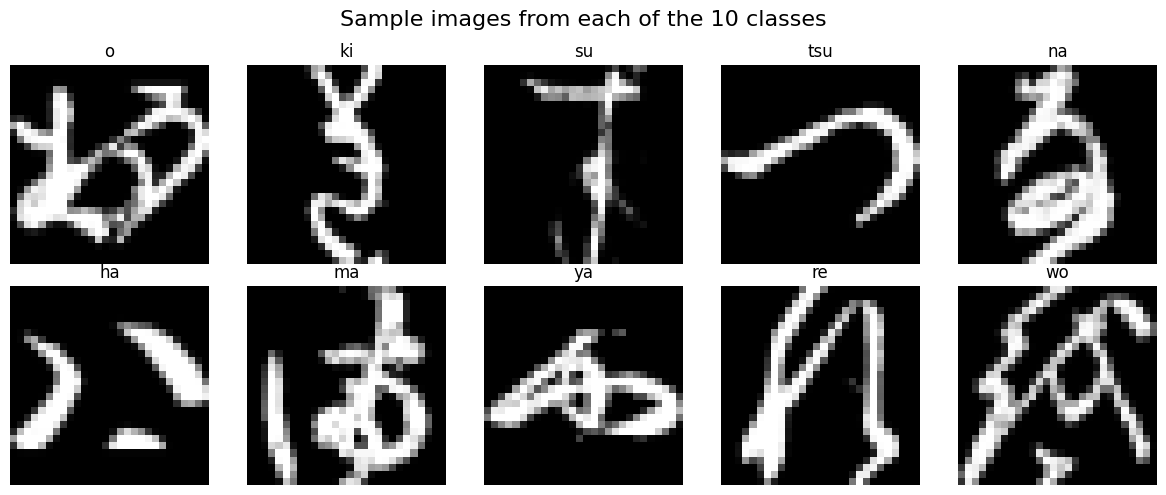

In [38]:
# YOUR CODE HERE
img_classes = {}
for img, label in full_train_dataset:
  if label not in img_classes:
    img_classes[label] = img
  if len(img_classes) == 10:
    break

fig, axes = plt.subplots(2, 5, figsize = (12, 5))
fig.suptitle("Sample images from each of the 10 classes", fontsize = 16)

for i, ax in enumerate(axes.flat):
  ax.imshow(img_classes[i], cmap = 'gray')
  ax.axis('off')
  ax.set_title(f'{class_names[i]}')

plt.tight_layout()
plt.show()

### 1.3 Data Scaling & Splitting (10 Marks)

**Your tasks:**
1. Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
2. Normalize the pixel values to the range [0, 1] by MinMax Scaling.
3. Split the training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
4. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (float32 tensors), `y_train, y_val, y_test` (long tensors)

In [39]:
# YOUR CODE HERE

# Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
X_train_full = full_train_dataset.data.numpy()
y_train_full = full_train_dataset.targets.numpy()

X_test = test_dataset_raw.data.numpy()
y_test = test_dataset_raw.targets.numpy()

# Normalize the pixel values to the range [0, 1] by MinMax Scaling.
X_train_full = X_train_full.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Split the training data into train (50,000) and validation (10,000) using train_test_split with random_state=42.
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size = 10000, random_state = 42)

# Convert all sets to PyTorch tensors — images as float32, labels as long.
X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.long)
y_val = torch.tensor(y_val, dtype = torch.long)
y_test = torch.tensor(y_test, dtype = torch.long)

In [40]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28)
assert X_train.dtype == torch.float32
assert y_train.dtype == torch.long
print("✅ Q1.3 Passed!")

✅ Q1.3 Passed!


---

## Question 2: Build PyTorch DataLoaders (15 Marks)

Create `TensorDataset` and `DataLoader` objects for train, validation, and test sets.

- **batch_size = 256**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [41]:
# YOUR CODE HERE

# create tensordataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# create dataloader
train_loader = DataLoader(train_dataset, batch_size = 256, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 256, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 256, shuffle = False)

In [42]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (256, 28, 28)
assert batch_y.dtype == torch.long
print("✅ Q2 Passed!")

✅ Q2 Passed!


---

## Question 3: Deep Neural Network Architecture (25 Marks)

Create a class `TranslateAIClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture. Since the input is `28x28`, the flattened size is **784**.

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28x28 → 784 |
| Linear | 784 → 512 |
| BatchNorm1d | Batch Normalization (512 features) |
| ReLU | Activation |
| Linear | 512 → 256 |
| BatchNorm1d | Batch Normalization (256 features) |
| ReLU | Activation |
| Linear | 256 → 128 |
| BatchNorm1d | Batch Normalization (128 features) |
| ReLU | Activation |
| Linear | 128 → 10 |

After defining the class, create an instance called `model` and print it.

In [43]:
# YOUR CODE HERE
class TranslateAIClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

  def forward(self, x):
    return self.model(x)

model = TranslateAIClassifier()
print(model)

TranslateAIClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [44]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10)
has_batchnorm = any(isinstance(m, nn.BatchNorm1d) for m in model.modules())
assert has_batchnorm, "Model must include BatchNorm1d layers"
print("✅ Q3 Passed!")

✅ Q3 Passed!


---

## Question 4: Advanced Training Pipeline (25 Marks)

### 4.1 Setup Optimizer and Loss (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.Adam` with `lr=0.001`
- Number of epochs: **15**

In [45]:
# YOUR CODE HERE
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
epochs = 15

### 4.2 PyTorch Training Pipeline (20 Marks)

Write the training loop for **15 epochs**.

For each epoch:
1. Set model to training mode (`model.train()`)
2. Train on `train_loader` (forward pass, calculate loss, backward pass, optimizer step)
3. Set model to evaluation mode (`model.eval()`)
4. Evaluate on `val_loader` and compute validation loss and accuracy.
5. Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}`

Store: `train_losses`, `val_losses` lists.

In [46]:
# YOUR CODE HERE

# Store: train_losses, val_losses lists.
train_losses = []
val_losses = []

for epoch in range(epochs):
  # Set model to training mode (model.train())
  model.train()
  train_loss_total = 0.0

  # Train on train_loader (forward pass, calculate loss, backward pass, optimizer step)
  for batch_features, batch_labels in train_loader:

    # forward pass
    optimizer.zero_grad()
    output = model(batch_features)

    # calculate loss
    loss = loss_func(output, batch_labels)

    # backward pass
    loss.backward()

    # optimizer step
    optimizer.step()

    train_loss_total += loss.item()

  train_loss_avg = train_loss_total / len(train_loader)
  train_losses.append(train_loss_avg)

  # Set model to evaluation mode (model.eval())
  model.eval()
  val_loss_total = 0.0
  correct = 0
  total = 0

  # Evaluate on val_loader and compute validation loss and accuracy.
  with torch.no_grad():
    for batch_features, batch_labels in val_loader:
      output = model(batch_features)
      loss = loss_func(output, batch_labels)

      val_loss_total += loss.item()

      predicted = torch.argmax(output, dim = 1)
      correct += (predicted == batch_labels).sum().item()
      total += batch_labels.shape[0]

    val_loss_avg = val_loss_total / len(val_loader)
    val_losses.append(val_loss_avg)

    # test accuracy
    val_acc = correct / total

    # Print: Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}
    print(f'Epoch: {epoch + 1}/{epochs} | Train Loss: {train_loss_avg:.4f} | Val Loss: {val_loss_avg:.4f}')

Epoch: 1/15 | Train Loss: 0.3780 | Val Loss: 0.1929
Epoch: 2/15 | Train Loss: 0.1358 | Val Loss: 0.1609
Epoch: 3/15 | Train Loss: 0.0792 | Val Loss: 0.1474
Epoch: 4/15 | Train Loss: 0.0518 | Val Loss: 0.1382
Epoch: 5/15 | Train Loss: 0.0348 | Val Loss: 0.1329
Epoch: 6/15 | Train Loss: 0.0310 | Val Loss: 0.1638
Epoch: 7/15 | Train Loss: 0.0212 | Val Loss: 0.1485
Epoch: 8/15 | Train Loss: 0.0151 | Val Loss: 0.1478
Epoch: 9/15 | Train Loss: 0.0196 | Val Loss: 0.1723
Epoch: 10/15 | Train Loss: 0.0139 | Val Loss: 0.1491
Epoch: 11/15 | Train Loss: 0.0121 | Val Loss: 0.1550
Epoch: 12/15 | Train Loss: 0.0156 | Val Loss: 0.1692
Epoch: 13/15 | Train Loss: 0.0135 | Val Loss: 0.1499
Epoch: 14/15 | Train Loss: 0.0138 | Val Loss: 0.1604
Epoch: 15/15 | Train Loss: 0.0147 | Val Loss: 0.1561


In [47]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
print("✅ Q4.2 Passed!")

✅ Q4.2 Passed!


---

## Question 5: Evaluation & Analytics (10 Marks)

### 5.1 Test Evaluation (5 Marks)
Evaluate the model on the **test set**.
- Print the Test Accuracy.
- Collect Test dataset's all predictions into a list called `all_preds`.

In [48]:
# YOUR CODE HERE
model.eval()
total = 0
correct = 0

# Collect Test dataset's all predictions into a list called all_preds.
all_preds = []

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    output = model(batch_features)
    _, predicted = torch.max(output, 1)

    correct += (predicted == batch_labels).sum().item()
    total += batch_labels.shape[0]

    all_preds.extend(predicted.tolist())

test_acc = 100 * correct / total

# Print the Test Accuracy.
print(f'Test Accuracy: {test_acc}')

Test Accuracy: 90.71


### 5.2 Plot Learning Curves (5 Marks)
Plot **Training Loss** and **Validation Loss** on the same figure across epochs. Include a legend and title.

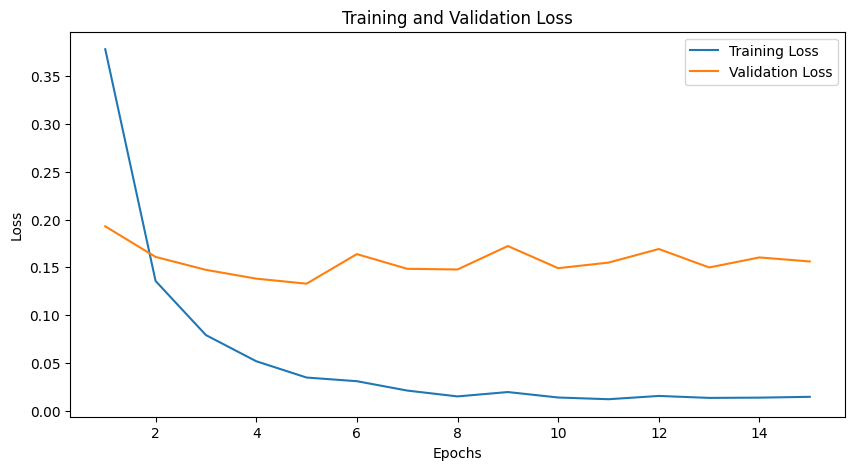

In [49]:
# YOUR CODE HERE
plt.figure(figsize = (10, 5))
plt.plot(range(1, epochs + 1), train_losses, label = 'Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### 5.3 Confusion Matrix & Analysis (5+5 Marks)
1. Plot the confusion matrix using `ConfusionMatrixDisplay`.
2. Write a brief markdown explanation of which ancient character classes are most frequently confused by the model based on the matrix.

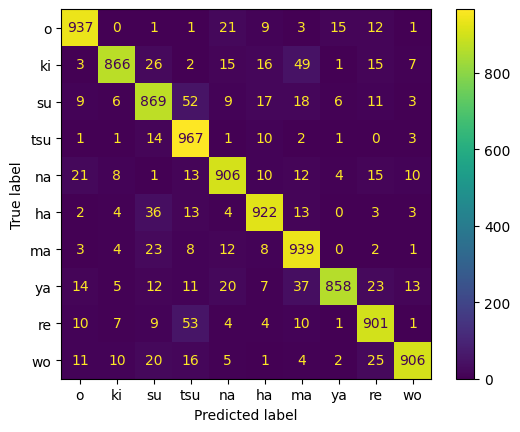

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE
# Plot the confusion matrix using ConfusionMatrixDisplay.
cm = confusion_matrix(y_test, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = class_names)
disp.plot()
plt.show()

*Double-click here to write your analysis*

**Your Analysis:**

From the Confusion Matrix plot we can see that the model has predicted a bunch of letters wrong / confused as another letter.

From the plot we can see that the model has predicted the letter "re" as "tsu" 53 times which is the highest wrong prediction in the graph. Apart from it the model has predicted "su" as "tsu" 52 times, "ki" as "ma" 49 times, "ha" as "su" 36 times, "wo" as "re" 25 times and "ma" as "su" 23 times. Apart from these letters other letters are predicted as accurate.

These wrong predictions happens because the letters or curvatures are seems to be similar in 28 x 28 grayscale image which makes it complex to correctly identify each letters.